In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, color
from matplotlib.patches import Rectangle


In [2]:
def calcular_energia_horizontal(imagem):
    imagem_cinza = color.rgb2gray(imagem)
    energia = np.abs(filters.sobel_h(imagem_cinza))
    return energia

def encontrar_e_remover_costura_horizontal(imagem, energia):
    linhas, colunas = energia.shape
    M = energia.copy()
    backtrack = np.zeros_like(M, dtype=int)

    for i in range(1, linhas):
        for j in range(colunas):
            if j == 0:
                idx = np.argmin(M[i-1:i+1, j])
                backtrack[i, j] = idx + i - 1
                min_energia = M[idx + i - 1, j]
            else:
                idx = np.argmin(M[i-1:i+1, j])
                backtrack[i, j] = idx + i - 1
                min_energia = M[idx + i - 1, j]
            M[i, j] += min_energia

    nova_imagem = np.zeros((linhas, colunas - 1, 3), dtype=imagem.dtype)
    j = np.argmin(M[-1, :])
    for i in reversed(range(linhas)):
        nova_imagem[i, :, 0] = np.delete(imagem[i, :, 0], [j])
        nova_imagem[i, :, 1] = np.delete(imagem[i, :, 1], [j])
        nova_imagem[i, :, 2] = np.delete(imagem[i, :, 2], [j])
        j = backtrack[i, j]
    return nova_imagem


def remover_linhas_horizontais(imagem, num_costuras):
    for _ in range(num_costuras):
        energia = calcular_energia_horizontal(imagem)
        imagem = encontrar_e_remover_costura_horizontal(imagem, energia)
    return imagem




In [3]:
def calcular_energia_vertical(imagem):
    # escala de cinza
    imagem_cinza = color.rgb2gray(imagem)
    # gradiente
    energia = np.abs(filters.sobel_v(imagem_cinza))
    return energia

def encontrar_e_remover_costura_vertical(imagem, energia):
    linhas, colunas = energia.shape
    M = energia.copy()
    backtrack = np.zeros_like(M, dtype=int)

    # matriz de energia acumulada
    for j in range(1, colunas):
        for i in range(linhas):
            if i == 0:
                idx = np.argmin(M[i:i+2, j-1])
                backtrack[i, j] = idx + i
                min_energia = M[idx + i, j-1]
            else:
                idx = np.argmin(M[i-1:i+2, j-1])
                backtrack[i, j] = idx + i - 1
                min_energia = M[idx + i - 1, j-1]
            M[i, j] += min_energia

    # Remover a costura
    nova_imagem = np.zeros((linhas - 1, colunas, 3), dtype=imagem.dtype)
    i = np.argmin(M[:, -1])
    for j in reversed(range(colunas)):
        nova_imagem[:, j, 0] = np.delete(imagem[:, j, 0], [i])
        nova_imagem[:, j, 1] = np.delete(imagem[:, j, 1], [i])
        nova_imagem[:, j, 2] = np.delete(imagem[:, j, 2], [i])
        i = backtrack[i, j]
    return nova_imagem


def remover_colunas_verticais(imagem, num_costuras):
    for _ in range(num_costuras):
        energia = calcular_energia_vertical(imagem)
        imagem = encontrar_e_remover_costura_vertical(imagem, energia)
    return imagem

In [4]:
def remover_objeto(imagem, mask):
    # Calcular a energia inicial
    energia = calcular_energia_horizontal(imagem)
    energia[mask > 0] += 1000  # Aumenta a energia na área da máscara

    # Determinar o número de costuras a serem removidas para linhas
    num_costuras_altura = int(np.sum(mask, axis=1).max())  # Para linhas

    # Remover linhas horizontais
    for _ in range(num_costuras_altura):
        imagem = encontrar_e_remover_costura_horizontal(imagem, energia)
        energia = calcular_energia_horizontal(imagem)  # Recalcular energia após a remoção

        # Ajustar a máscara para a nova dimensão da imagem
        mask = mask[:imagem.shape[0], :]

    # Ajustar energia para a nova imagem
    energia = calcular_energia_vertical(imagem)
    energia[mask > 0] += 1000  # Reajustar a energia na nova imagem

    # Determinar o número de costuras a serem removidas para colunas
    num_costuras_largura = int(np.sum(mask, axis=0).max())  # Para colunas

    # Remover colunas verticais
    for _ in range(num_costuras_largura):
        imagem = encontrar_e_remover_costura_vertical(imagem, energia)
        energia = calcular_energia_vertical(imagem)  # Recalcular energia após a remoção

        # Ajustar a máscara para a nova dimensão da imagem
        mask = mask[:, :imagem.shape[1]]

    return imagem


In [5]:
imagem_original = io.imread('./ovos.jpg')

remove linhas [Ok]


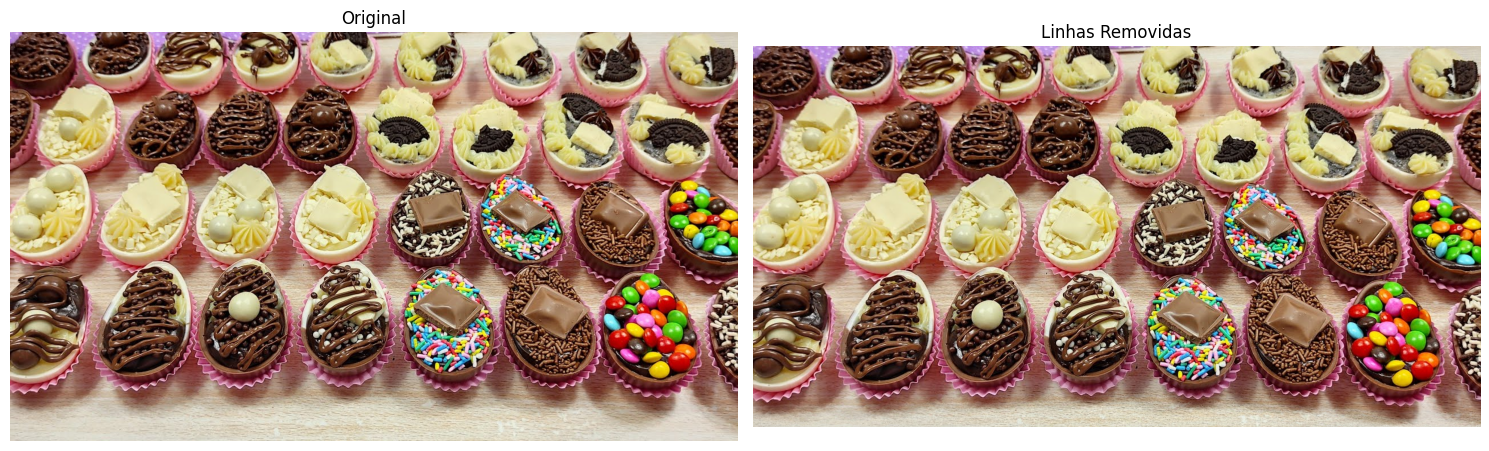

In [55]:

# Remover linhas horizontais
imagem_com_linhas_removidas = remover_linhas_horizontais(imagem_original, 50)
print("remove linhas [Ok]")

# Mostrar as imagens resultantes
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].imshow(imagem_original)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(imagem_com_linhas_removidas)
ax[1].set_title('Linhas Removidas')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [56]:
print(imagem_original.shape)
print(imagem_com_linhas_removidas.shape)


(720, 1280, 3)
(670, 1280, 3)


In [6]:
# Definir variáveis para as coordenadas e dimensões do retângulo
x_inicio = 150
y_inicio = 100
largura = 10
altura = 10

# Criar a máscara para o objeto a ser removido
mask = np.zeros(imagem_original.shape[:2], dtype=np.uint8)
mask[y_inicio:y_inicio + altura, x_inicio:x_inicio + largura] = 1

# Remover o objeto definido pela máscara
imagem_sem_objeto = remover_objeto(imagem_original, mask)
print("remove objeto [Ok]")

# Mostrar as imagens resultantes
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax[0].imshow(imagem_original)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(imagem_sem_objeto)
ax[1].set_title('Objeto Removido')
ax[1].axis('off')

plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along dimension 1; dimension is 1270 but corresponding boolean dimension is 1280

In [ ]:
print(imagem_original.shape)
print(imagem_sem_objeto.shape)